# NickelScope — Generator Figure Proposal
Menghasilkan **10 figure** siap-proposal (north arrow, scale bar, basemap satelit, legend) -> `figures/`.

**Run All** berurutan. Data: `data/` & `kolaka/`.

## 0 — Setup, helper & data

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import os, numpy as np, pandas as pd, geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns
import contextily as cx
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

os.makedirs("figures", exist_ok=True)

# ---------- Style profesional ----------
NAVY="#0a3d62"; GOLD="#c59428"; RED="#c0392b"; GRAY="#7f8c8d"
PAL=["#000080","#0000ff","#00ffff","#ffff00","#ff8000","#ff0000"]
PROSPECT_CMAP=mpl.colors.LinearSegmentedColormap.from_list("prospect",PAL)
mpl.rcParams.update({"font.family":"DejaVu Sans","font.size":10,
  "axes.titlesize":13,"axes.titleweight":"bold","axes.labelsize":10,
  "figure.dpi":120,"savefig.dpi":200,"savefig.bbox":"tight","axes.edgecolor":"#333333"})
FEATS=["iron_oxide","ferrous","clay","ndvi","elevation","slope","curvature","twi"]

# ---------- Data ----------
DATA="data" if os.path.exists("data/nickelscope_features_v2.csv") else "."
df=pd.read_csv(f"{DATA}/nickelscope_features_v2.csv")
geo=gpd.read_file("kolaka/geologi_ar_100k_kolaka.shp")[["NAMOBJ","geometry"]]
um_m=unary_union(geo[geo.NAMOBJ=="Ultramafic Complex"].to_crs(32751).geometry.tolist())
pts32=gpd.GeoDataFrame(df.copy(),geometry=[Point(xy) for xy in zip(df.lon,df.lat)],crs=4326).to_crs(32751)
df["dist_um"]=pts32.distance(um_m).values
df["onUM"]=df.dist_um<=500
gpts=gpd.GeoDataFrame(df.copy(),geometry=[Point(xy) for xy in zip(df.lon,df.lat)],crs=4326).to_crs(3857)
geo3857=geo.to_crs(3857); um3857=geo3857[geo3857.NAMOBJ=="Ultramafic Complex"]
LATC=-4.15; M2=1/np.cos(np.radians(LATC))  # koreksi skala Web Mercator

def basemap(ax,src=cx.providers.Esri.WorldImagery):
    try: cx.add_basemap(ax,source=src,attribution_size=5)
    except Exception as e: print("  (basemap skip:",e,")")

def north_arrow(ax,x=0.94,y=0.96):
    ax.annotate("N",xy=(x,y),xytext=(x,y-0.10),xycoords="axes fraction",
        arrowprops=dict(facecolor="white",edgecolor="black",width=4,headwidth=12),
        ha="center",va="center",fontsize=12,fontweight="bold",color="white")

def scalebar(ax,km=5):
    x0,x1=ax.get_xlim(); y0,y1=ax.get_ylim(); L=km*1000*M2
    xs=x0+(x1-x0)*0.06; ys=y0+(y1-y0)*0.06
    ax.add_line(Line2D([xs,xs+L],[ys,ys],color="white",lw=4,solid_capstyle="butt"))
    ax.add_line(Line2D([xs,xs+L],[ys,ys],color="black",lw=2,solid_capstyle="butt"))
    ax.text(xs+L/2,ys+(y1-y0)*0.015,f"{km} km",ha="center",va="bottom",
            color="white",fontsize=9,fontweight="bold")

def finish(ax,title):
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    north_arrow(ax); scalebar(ax)

def spatial_cv(data,feats):
    y=data.label.values.astype(int); BLK=0.03
    gx=((data.lon-data.lon.min())//BLK).astype(int).astype(str)
    gy=((data.lat-data.lat.min())//BLK).astype(int).astype(str)
    grp=(gx+"_"+gy).values
    m=RandomForestClassifier(n_estimators=400,min_samples_leaf=2,class_weight="balanced",random_state=42,n_jobs=-1)
    cv=StratifiedGroupKFold(min(5,pd.Series(grp).nunique()),shuffle=True,random_state=42)
    p=cross_val_predict(m,data[feats].values,y,cv=cv,groups=grp,method="predict_proba",n_jobs=-1)[:,1]
    return y,p

# Precompute spatial CV (dipakai fig8-10)
yo,po=spatial_cv(df,FEATS)
yd,pd_=spatial_cv(df[df.onUM],FEATS)
print("Setup selesai. Titik:",len(df))

ModuleNotFoundError: No module named 'matplotlib'

## 1 — Lokasi Studi

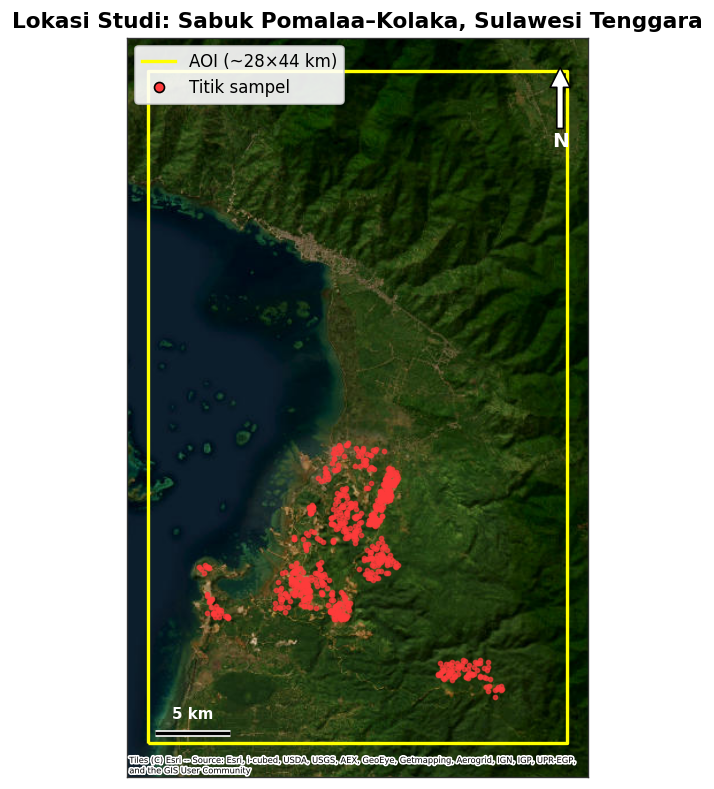

fig1 OK


In [2]:
fig,ax=plt.subplots(figsize=(8,8))
gpts.plot(ax=ax,color="#ff3b3b",markersize=6,alpha=.7)
aoi=gpd.GeoSeries.from_wkt([f"POLYGON((121.50 -4.35,121.75 -4.35,121.75 -3.95,121.50 -3.95,121.50 -4.35))"],crs=4326).to_crs(3857)
aoi.boundary.plot(ax=ax,color="yellow",lw=2)
basemap(ax)
finish(ax,"Lokasi Studi: Sabuk Pomalaa–Kolaka, Sulawesi Tenggara")
ax.legend(handles=[Line2D([],[],color="yellow",lw=2,label="AOI (~28×44 km)"),
          Line2D([],[],marker="o",color="none",markerfacecolor="#ff3b3b",label="Titik sampel")],
          loc="upper left",framealpha=.9)
fig.savefig("figures/fig1_lokasi.png"); plt.show(); print("fig1 OK")

## 2 — Peta Geologi

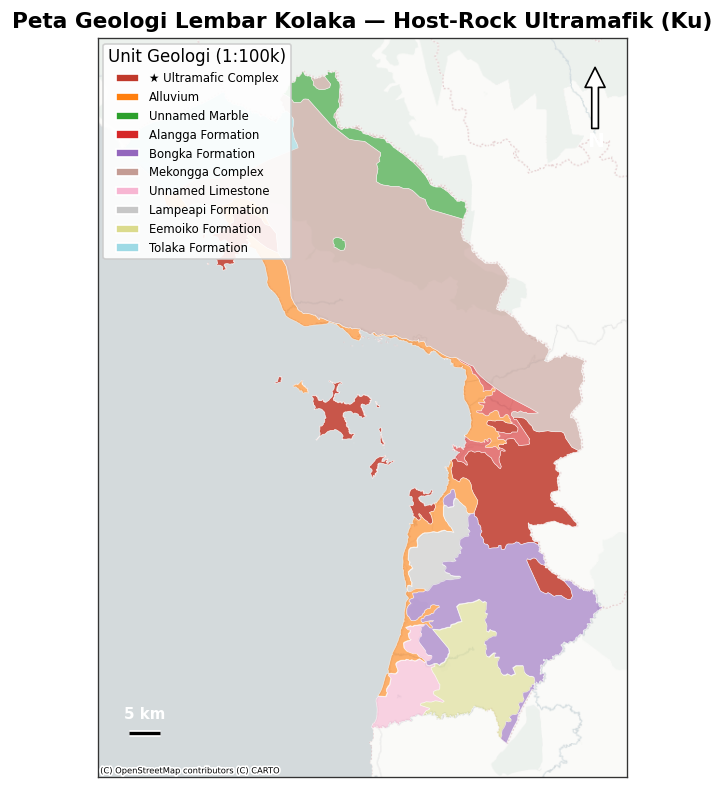

fig2 OK


In [3]:
fig,ax=plt.subplots(figsize=(8.5,8))
units=geo3857.NAMOBJ.value_counts().index.tolist()
cmap=plt.cm.tab20(np.linspace(0,1,len(units)))
cdict=dict(zip(units,cmap))
for u in units:
    sub=geo3857[geo3857.NAMOBJ==u]
    c=RED if u=="Ultramafic Complex" else cdict[u]
    sub.plot(ax=ax,color=c,ec="white",lw=.4,alpha=.85 if u=="Ultramafic Complex" else .6)
handles=[Patch(facecolor=(RED if u=="Ultramafic Complex" else cdict[u]),
         ec="white",label=("★ "+u if u=="Ultramafic Complex" else u)) for u in units]
ax.legend(handles=handles,loc="upper left",fontsize=7,framealpha=.9,title="Unit Geologi (1:100k)")
basemap(ax,cx.providers.CartoDB.PositronNoLabels)
finish(ax,"Peta Geologi Lembar Kolaka — Host-Rock Ultramafik (Ku)")
fig.savefig("figures/fig2_geologi.png"); plt.show(); print("fig2 OK")

## 3 — Validasi Host-Rock (penyaringan label)

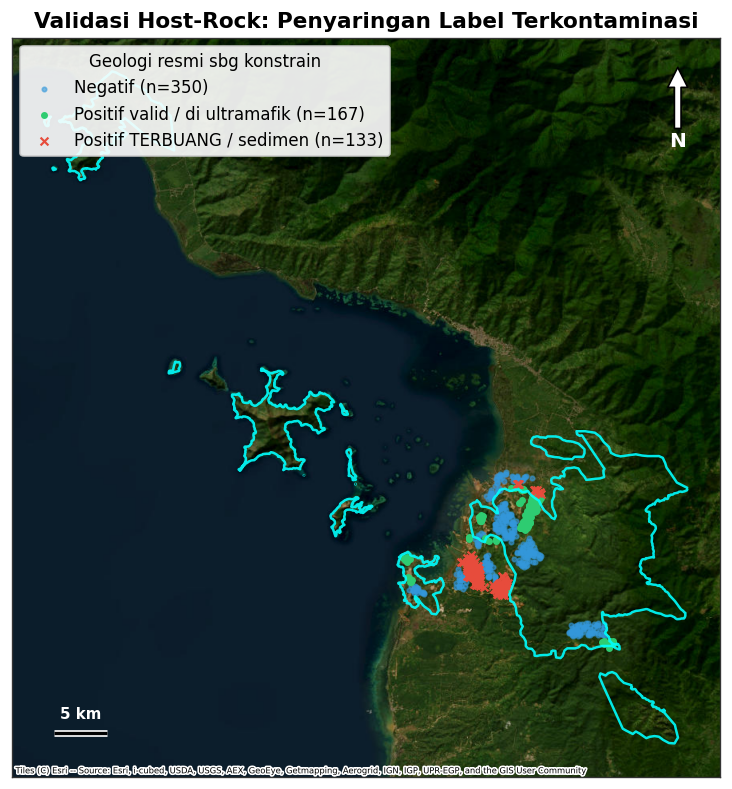

fig3 OK


In [4]:
fig,ax=plt.subplots(figsize=(8.5,8))
um3857.plot(ax=ax,color="none",ec="cyan",lw=1.5,alpha=.9,zorder=3)
neg=gpts[gpts.label==0]; posI=gpts[(gpts.label==1)&(gpts.onUM)]; posO=gpts[(gpts.label==1)&(~gpts.onUM)]
neg.plot(ax=ax,color="#3498db",markersize=7,alpha=.6,label=f"Negatif (n={len(neg)})")
posI.plot(ax=ax,color="#2ecc71",markersize=10,label=f"Positif valid / di ultramafik (n={len(posI)})")
posO.plot(ax=ax,color="#e74c3c",marker="x",markersize=22,lw=1.3,label=f"Positif TERBUANG / sedimen (n={len(posO)})")
basemap(ax)
finish(ax,"Validasi Host-Rock: Penyaringan Label Terkontaminasi")
leg=ax.legend(loc="upper left",framealpha=.9)
leg.set_title("Geologi resmi sbg konstrain")
fig.savefig("figures/fig3_label_hostrock.png"); plt.show(); print("fig3 OK")

## 4 — Histogram Jarak ke Ultramafik

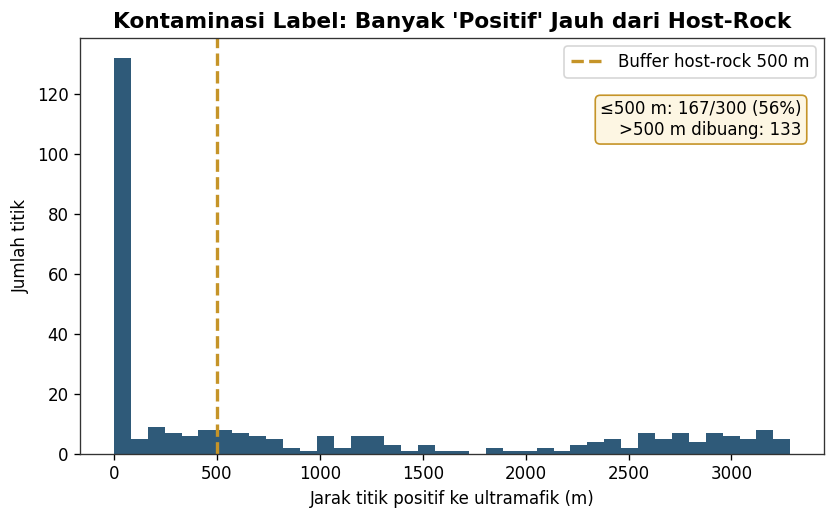

fig4 OK


In [5]:
fig,ax=plt.subplots(figsize=(8,4.5))
pos=df[df.label==1]
ax.hist(pos.dist_um,bins=40,color=NAVY,alpha=.85)
ax.axvline(500,color=GOLD,lw=2,ls="--",label="Buffer host-rock 500 m")
ax.set_xlabel("Jarak titik positif ke ultramafik (m)"); ax.set_ylabel("Jumlah titik")
ax.set_title("Kontaminasi Label: Banyak 'Positif' Jauh dari Host-Rock")
n_in=(pos.dist_um<=500).sum()
ax.text(.97,.85,f"≤500 m: {n_in}/{len(pos)} ({100*n_in/len(pos):.0f}%)\n>500 m dibuang: {len(pos)-n_in}",
        transform=ax.transAxes,ha="right",va="top",bbox=dict(boxstyle="round",fc="#fdf6e3",ec=GOLD))
ax.legend(); fig.savefig("figures/fig4_dist_hist.png"); plt.show(); print("fig4 OK")

## 5 — Separasi Fitur

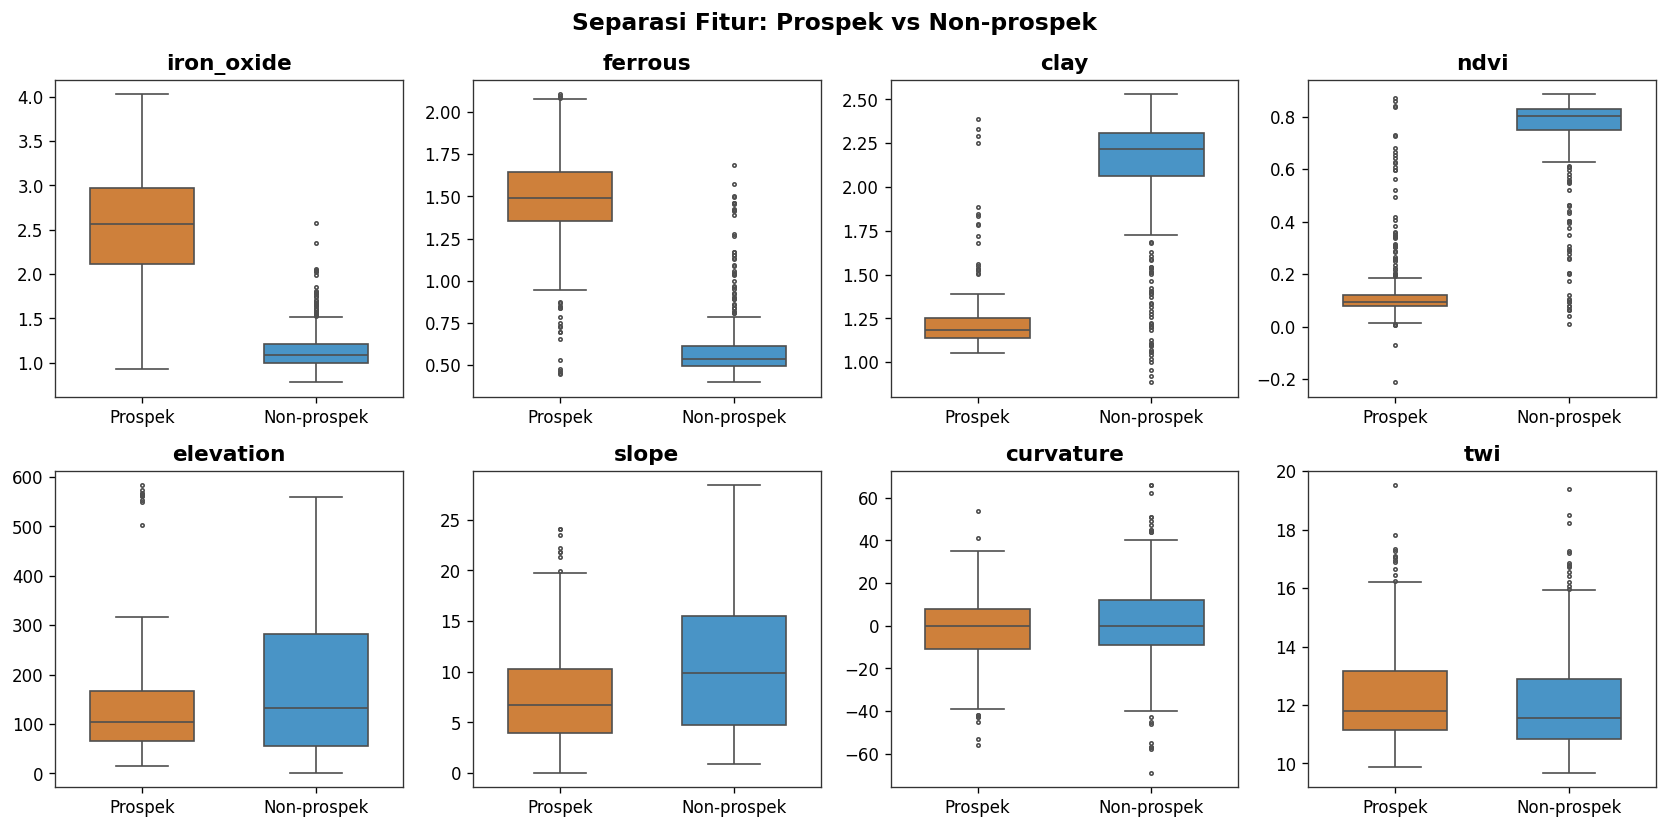

fig5 OK


In [6]:
dd=df.copy(); dd["Kelas"]=dd.label.map({1:"Prospek",0:"Non-prospek"})
fig,axes=plt.subplots(2,4,figsize=(14,7))
for f,ax in zip(FEATS,axes.ravel()):
    sns.boxplot(data=dd,x="Kelas",y=f,ax=ax,palette={"Prospek":"#e67e22","Non-prospek":"#3498db"},width=.6,fliersize=2)
    ax.set_title(f); ax.set_xlabel(""); ax.set_ylabel("")
fig.suptitle("Separasi Fitur: Prospek vs Non-prospek",fontsize=14,fontweight="bold")
fig.tight_layout(); fig.savefig("figures/fig5_fitur_boxplot.png"); plt.show(); print("fig5 OK")

## 6 — Korelasi Fitur

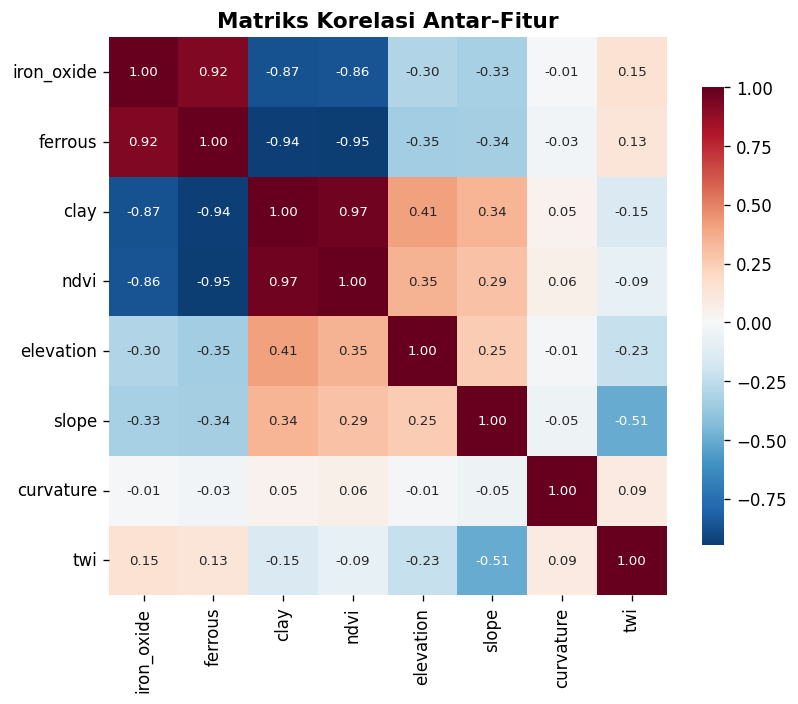

fig6 OK


In [7]:
fig,ax=plt.subplots(figsize=(7.5,6.2))
sns.heatmap(df[FEATS].corr(),annot=True,fmt=".2f",cmap="RdBu_r",center=0,
            square=True,cbar_kws={"shrink":.8},ax=ax,annot_kws={"size":8})
ax.set_title("Matriks Korelasi Antar-Fitur"); fig.savefig("figures/fig6_korelasi.png"); plt.show(); print("fig6 OK")

## 7 — Feature Importance

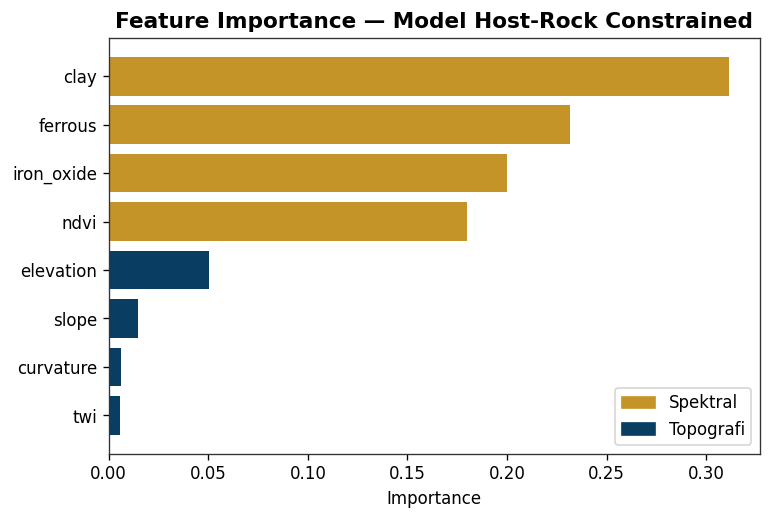

fig7 OK


In [8]:
dom=df[df.onUM]
m=RandomForestClassifier(n_estimators=400,min_samples_leaf=2,class_weight="balanced",random_state=42,n_jobs=-1)
m.fit(dom[FEATS],dom.label.astype(int))
imp=pd.Series(m.feature_importances_,index=FEATS).sort_values()
fig,ax=plt.subplots(figsize=(7,4.5))
colors=[GOLD if f in["iron_oxide","ferrous","clay","ndvi"] else NAVY for f in imp.index]
ax.barh(imp.index,imp.values,color=colors)
ax.set_title("Feature Importance — Model Host-Rock Constrained")
ax.set_xlabel("Importance")
ax.legend(handles=[Patch(color=GOLD,label="Spektral"),Patch(color=NAVY,label="Topografi")],loc="lower right")
fig.savefig("figures/fig7_importance.png"); plt.show(); print("fig7 OK")

## 8 — ROC — Spatial CV

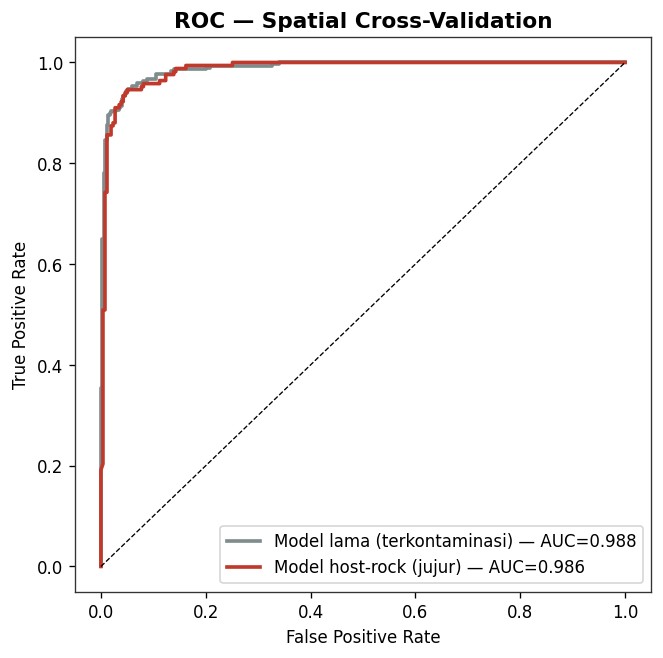

fig8 OK


In [9]:
yo,po=spatial_cv(df,FEATS)
yd,pd_=spatial_cv(df[df.onUM],FEATS)
fig,ax=plt.subplots(figsize=(6.2,6))
for y,p,lab,c in [(yo,po,"Model lama (terkontaminasi)",GRAY),(yd,pd_,"Model host-rock (jujur)",RED)]:
    fpr,tpr,_=roc_curve(y,p); ax.plot(fpr,tpr,color=c,lw=2.2,label=f"{lab} — AUC={roc_auc_score(y,p):.3f}")
ax.plot([0,1],[0,1],"k--",lw=.8)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC — Spatial Cross-Validation"); ax.legend(loc="lower right")
fig.savefig("figures/fig8_roc.png"); plt.show(); print("fig8 OK")

## 9 — Confusion Matrix

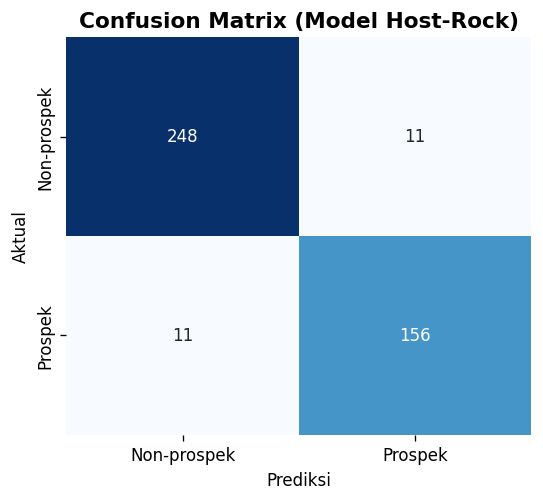

fig9 OK


In [10]:
cm=confusion_matrix(yd,(pd_>=.5).astype(int))
fig,ax=plt.subplots(figsize=(5,4.3))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",cbar=False,ax=ax,
    xticklabels=["Non-prospek","Prospek"],yticklabels=["Non-prospek","Prospek"])
ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual"); ax.set_title("Confusion Matrix (Model Host-Rock)")
fig.savefig("figures/fig9_confusion.png"); plt.show(); print("fig9 OK")

## 10 — Peta Prospektivitas Final

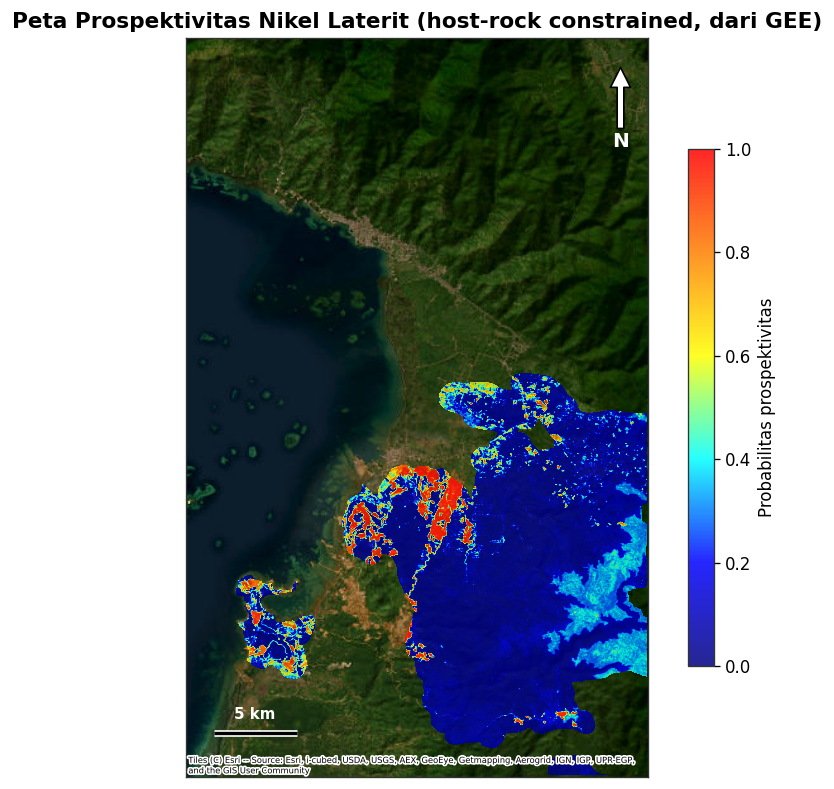

fig10 OK (raster)


In [11]:
import glob
tif=None
for c in ["data/nickelscope_prospectivity_hostrock.tif","nickelscope_prospectivity_hostrock.tif",
          "data/nickelscope_prospectivity.tif","nickelscope_prospectivity.tif",
          os.path.expanduser("~/Downloads/nickelscope_prospectivity_hostrock.tif")]:
    if os.path.exists(c): tif=c; break
fig,ax=plt.subplots(figsize=(8.5,8))
if tif:
    import rasterio; from rasterio.warp import transform_bounds
    with rasterio.open(tif) as r:
        arr=r.read(1,masked=True)
        b=transform_bounds(r.crs,"EPSG:3857",*r.bounds)
    im=ax.imshow(arr,extent=[b[0],b[2],b[1],b[3]],cmap=PROSPECT_CMAP,vmin=0,vmax=1,zorder=2,alpha=.85)
    basemap(ax); plt.colorbar(im,ax=ax,shrink=.7,label="Probabilitas prospektivitas")
    sub="(host-rock constrained, dari GEE)"
else:
    dd=df[df.onUM].copy();
    if pd_ is not None: dd=dd.iloc[:len(pd_)].copy(); dd["prob"]=pd_
    else: dd["prob"]=dd.label
    g=gpd.GeoDataFrame(dd,geometry=[Point(xy) for xy in zip(dd.lon,dd.lat)],crs=4326).to_crs(3857)
    g.plot(ax=ax,column="prob",cmap=PROSPECT_CMAP,markersize=22,vmin=0,vmax=1,legend=True,
           legend_kwds={"shrink":.7,"label":"Probabilitas (out-of-fold)"})
    um3857.plot(ax=ax,color="none",ec="cyan",lw=1.2)
    basemap(ax); sub="(prob. titik validasi — peta penuh via GEE script 07)"
finish(ax,"Peta Prospektivitas Nikel Laterit "+sub)
fig.savefig("figures/fig10_prospektivitas.png"); plt.show(); print("fig10 OK ("+("raster" if tif else "titik")+")")